# Explore Loss Functions

In this section, the model will be trained using the following loss functions:

1. MSE
2. MAE
3. Huber
4. Adaptive

The $R^2$ score will also be computed for each loss function.

## Libraries

In [12]:
# Prevent OpenMP runtime conflict between libraries like PyTorch, TensorFlow, and NumPy on Windows
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
import os
sys.path.append(os.path.abspath(".."))

import importlib
import src.training_utils as tu
importlib.reload(tu)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

## Load Data
Load the data prepared in `01_data_preparation.ipynb`.

In [2]:
data = torch.load('../saved_values/data.pt', weights_only=False)

x_train = data["x_train"]
y_train = data["y_train"]

x_valid = data["x_valid"]
y_valid = data["y_valid"]

x_test = data["x_test"]
y_test = data["y_test"]

## Convert to Tensors

Since the data is currently in NumPy array format, I will convert it to PyTorch tensors.

In [3]:
x_train = torch.FloatTensor(x_train)
y_train = torch.FloatTensor(y_train)

x_valid = torch.FloatTensor(x_valid)
y_valid = torch.FloatTensor(y_valid)

x_test = torch.FloatTensor(x_test)
y_test = torch.FloatTensor(y_test)

## Data Loader

Create data loaders for the training, validation, and test sets.

In [4]:
train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

valid_dataset = TensorDataset(x_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=256)

test_dataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=256)

## Define the Model Architecture

In [13]:
model = tu.Model(in_features=20, h1=64, h2=32, out_features=1)

## Optimizer
The optimizer used in this notebook is Adam.

In [14]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Loss functions
In this section I will train the model with these loss functions:
1. MSE
2. MAE
3. Huber
4. Adaptive

### 1. Mean Squared Error (MSE)
$$
\mathcal{L}_{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

<p align="center">
  <img src="../assets/MSE.png" width="20%">
</p>

In [28]:
loss_fn = nn.MSELoss()

In [10]:
trainer = tu.Trainer(model=model, optimizer=optimizer, loss_fn=loss_fn)

history = trainer.fit(train_loader, valid_loader, epochs=300, name="MSE")

Output()

          Epoch 10/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1351 │     0.2342 │
│ R²     │ 0.8649 │     0.7797 │
└────────┴────────┴────────────┘

          Epoch 20/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1353 │     0.2344 │
│ R²     │ 0.8647 │     0.7797 │
└────────┴────────┴────────────┘

          Epoch 30/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1355 │     0.2419 │
│ R²     │ 0.8644 │     0.7746 │
└────────┴────────┴────────────┘

          Epoch 40/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1331 │     0.2365 │
│ R²     │ 0.8669 │     0.7786 │
└────────┴────────┴────────────┘

...

         Epoch 260/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1209 │     0.2330 │
│ R²     │ 0.8790 │     0.7815 │
└────────┴────────┴────────────┘

         Epoch 270/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1224 │     0.2342 │
│ R²     │ 0.8777 │     0.7787 │
└────────┴────────┴────────────┘

         Epoch 280/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1209 │     0.2430 │
│ R²     │ 0.8792 │     0.7731 │
└────────┴────────┴────────────┘

         Epoch 290/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1197 │     0.2434 │
│ R²     │ 0.8803 │     0.7760 │
└────────┴────────┴────────────┘

         Epoch 300/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1206 │     0.2452 │
│ R²     │ 0.8794 │     0.7734 │
└────────┴────────┴────────────┘

#### Plot the Results

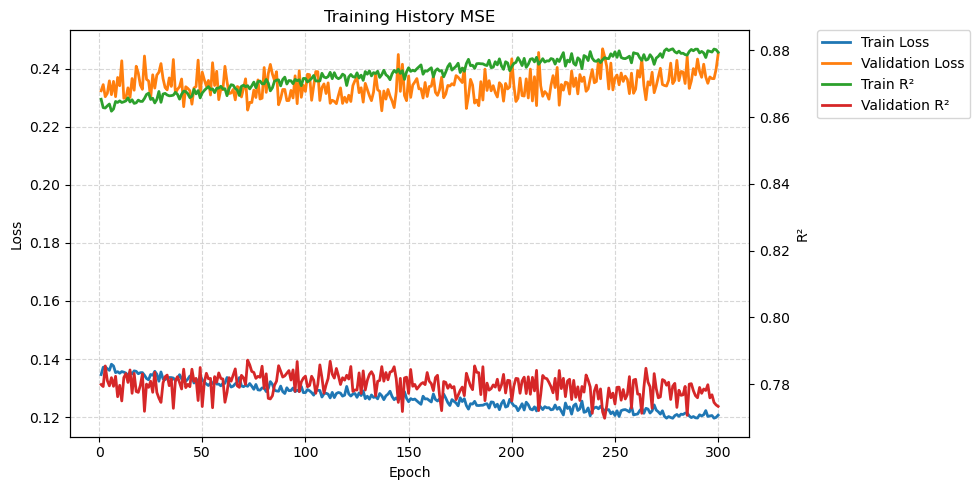

In [12]:
tu.plot_training_history(history, "MSE")

### 2. Mean Absolute Error (MAE)
$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

<p align="center">
  <img src="../assets/MAE.png" width="20%">
</p>

In [22]:
loss_fn = nn.L1Loss()

In [23]:
trainer = tu.Trainer(model=model, optimizer=optimizer, loss_fn=loss_fn)

history = trainer.fit(train_loader, valid_loader, epochs=300, log_every=10, name="MAE")

Output()

          Epoch 1/300           
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.4962 │     0.3916 │
│ R²     │ 0.4985 │     0.6838 │
└────────┴────────┴────────────┘

          Epoch 10/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.3270 │     0.3475 │
│ R²     │ 0.7589 │     0.7347 │
└────────┴────────┴────────────┘

          Epoch 20/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.3087 │     0.3305 │
│ R²     │ 0.7772 │     0.7618 │
└────────┴────────┴────────────┘

          Epoch 30/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2970 │     0.3178 │
│ R²     │ 0.7897 │     0.7753 │
└────────┴────────┴────────────┘

...

         Epoch 260/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2517 │     0.2970 │
│ R²     │ 0.8393 │     0.7913 │
└────────┴────────┴────────────┘

         Epoch 270/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2510 │     0.3009 │
│ R²     │ 0.8390 │     0.7854 │
└────────┴────────┴────────────┘

         Epoch 280/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2503 │     0.2998 │
│ R²     │ 0.8402 │     0.7908 │
└────────┴────────┴────────────┘

         Epoch 290/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2515 │     0.2967 │
│ R²     │ 0.8399 │     0.7857 │
└────────┴────────┴────────────┘

         Epoch 300/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2503 │     0.2978 │
│ R²     │ 0.8402 │     0.7870 │
└────────┴────────┴────────────┘

#### Plot the Results

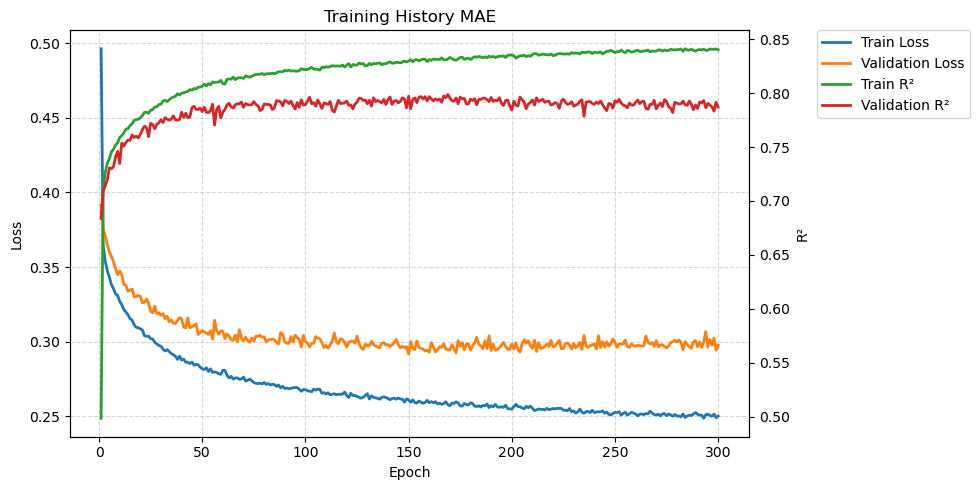

In [24]:
tu.plot_training_history(history, "MAE")

### 3. Huber
$$
L_\delta(e)=
\begin{cases}
\frac{1}{2}e^2, & |e| \le \delta \\
\delta \left(|e|-\frac{1}{2}\delta\right), & |e| > \delta
\end{cases}
$$


<p align="center">
  <img src="../assets/Huber.png" width="20%">
</p>

In [35]:
loss_fn = nn.HuberLoss()

In [36]:
trainer = tu.Trainer(model=model, optimizer=optimizer, loss_fn=loss_fn)

history = trainer.fit(train_loader, valid_loader, epochs=300, log_every=10, name="Huber")

Output()

          Epoch 1/300           
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2097 │     0.1457 │
│ R²     │ 0.5152 │     0.6852 │
└────────┴────────┴────────────┘

          Epoch 10/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1049 │     0.1167 │
│ R²     │ 0.7705 │     0.7488 │
└────────┴────────┴────────────┘

          Epoch 20/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.0966 │     0.1097 │
│ R²     │ 0.7891 │     0.7670 │
└────────┴────────┴────────────┘

          Epoch 30/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.0927 │     0.1036 │
│ R²     │ 0.7980 │     0.7748 │
└────────┴────────┴────────────┘

...

         Epoch 260/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.0694 │     0.0994 │
│ R²     │ 0.8521 │     0.7903 │
└────────┴────────┴────────────┘

         Epoch 270/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.0681 │     0.1008 │
│ R²     │ 0.8550 │     0.7822 │
└────────┴────────┴────────────┘

         Epoch 280/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.0679 │     0.1001 │
│ R²     │ 0.8558 │     0.7859 │
└────────┴────────┴────────────┘

         Epoch 290/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.0678 │     0.0996 │
│ R²     │ 0.8558 │     0.7858 │
└────────┴────────┴────────────┘

         Epoch 300/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.0680 │     0.1007 │
│ R²     │ 0.8556 │     0.7883 │
└────────┴────────┴────────────┘

#### Plot the Results

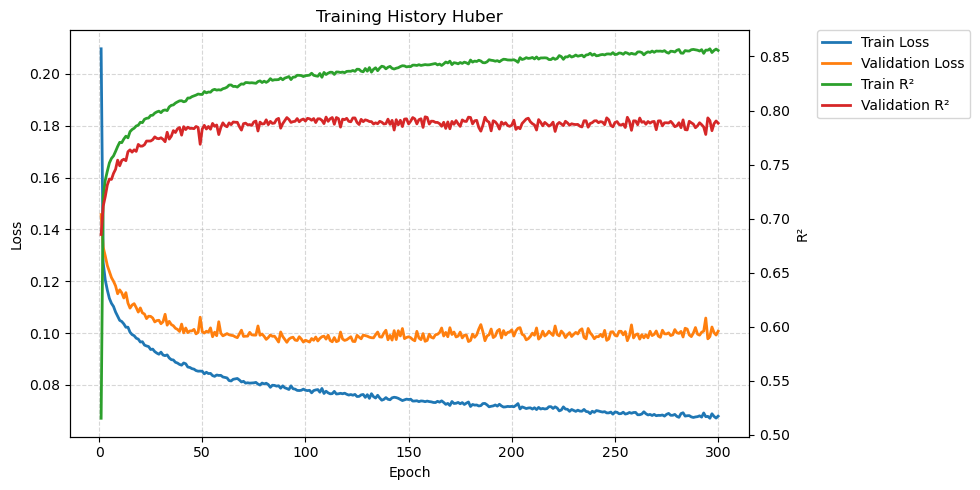

In [37]:
tu.plot_training_history(history, "Huber")

### 4. Adaptive
This section on Adaptive Robust Loss is based on the work by Jonathan T. Barron:  
*A General and Adaptive Robust Loss Function*, 2019. [Paper link](https://arxiv.org/abs/1701.03077)

Adaptive loss allows us to obtain a variety of loss functions by adjusting the value of $\alpha$.


- If $\alpha$ = 2:

$$
\frac{1}{2}(\frac{x}{c})^2
$$

When $\alpha = 2$, the adaptive loss reduces to the standard quadratic loss, which is equivalent to the **Mean Squared Error (MSE)**. This loss penalizes larger errors more heavily and is sensitive to outliers.

<p align="center">
  <img src="../assets/Adaptive_Loss_Quadratic.png" width="20%">
</p>


- If $\alpha$ = 0:

$$
\log(\frac{1}{2}(\frac{x}{c})^2 + 1)
$$

When $\alpha = 0$, the adaptive loss reduces to the **Cauchy loss**, which is also known as the Lorentzian loss.
*Barron, 2019, A General and Adaptive Robust Loss Function*. [Paper link](https://arxiv.org/abs/1701.03077)

This formulation provides a strongly robust objective that significantly reduces the influence of outliers by growing logarithmically rather than quadratically.

<p align="center">
  <img src="../assets/Adaptive_Loss_Cauchy.png" width="20%">
</p>


- If $\alpha \rightarrow -\infty$:

$$
L(x) =
1 -
\exp\left(
-\frac{1}{2}
\left(
\frac{x}{c}
\right)^2
\right)
$$

When $\alpha \rightarrow -\infty$, the adaptive loss reduces to the **Welsch loss**.

*Dennis Jr. & Welsch, 1978, Techniques for Nonlinear Least Squares and Robust Regression.* [Paper link](https://www.tandfonline.com/doi/abs/10.1080/03610917808812083)

This loss strongly suppresses the influence of large errors by applying an exponential penalty. Unlike quadratic losses, the growth of the loss saturates for large residuals, making it highly robust to outliers.

<p align="center">
  <img src="../assets/Adaptive_Loss_Welsch.png" width="20%">
</p>


- If $\alpha$ = 1 or $\alpha$ = -2:

$$
L(x;\alpha,c)=
\frac{|\alpha-2|}{\alpha}
\left(
\left(
\frac{\left(\frac{x}{c}\right)^2}{|\alpha-2|}+1
\right)^{\frac{\alpha}{2}}
-1
\right)
$$

When α = 1, the adaptive loss reduces to the **Charbonnier loss**.
*Charbonnier et al., 1994, Two-parameter robust estimator for image restoration*. [Paper link](https://ieeexplore.ieee.org/document/413553).

This loss is a smooth approximation of the L1 loss. It grows linearly for large errors, which makes it more robust to outliers compared to the standard quadratic loss, while still being differentiable at zero for stable optimization.

<p align="center">
  <img src="../assets/Adaptive_Loss_Charbonnier.png" width="20%">
</p>

When α = -2, the adaptive loss reduces to the **Geman-McClure loss**.
*German & McClure, 1987, Robust regression using a bounded influence function*. [Paper link](https://www.dam.brown.edu/people/geman/Homepage/Image%20processing,%20image%20analysis,%20Markov%20random%20fields,%20and%20MCMC/1985GemanMcClureASA.pdf).

This loss is robust to outliers: it grows sub-quadratically for large errors, limiting the influence of extreme deviations. For small errors, it behaves similarly to the L2 loss, ensuring smooth gradients and stable optimization.

<p align="center">
  <img src="../assets/Adaptive_Loss_Geman-McClure.png" width="20%">
</p>

#### 4.1 Quadratic Loss ($\alpha$ = 2)

In [15]:
loss_fn = lambda outputs, targets: tu.Adaptive_loss(outputs, targets, alpha=2)

In [16]:
trainer = tu.Trainer(model=model, optimizer=optimizer, loss_fn=loss_fn)

history = trainer.fit(train_loader, valid_loader, epochs=300, log_every=10, name="Adaptive_Quadratic")

Output()

          Epoch 1/300           
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.2475 │     0.1578 │
│ R²     │ 0.5047 │     0.6940 │
└────────┴────────┴────────────┘

          Epoch 10/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1154 │     0.1299 │
│ R²     │ 0.7691 │     0.7542 │
└────────┴────────┴────────────┘

          Epoch 20/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1066 │     0.1226 │
│ R²     │ 0.7870 │     0.7666 │
└────────┴────────┴────────────┘

          Epoch 30/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.1001 │     0.1207 │
│ R²     │ 0.7996 │     0.7674 │
└────────┴────────┴────────────┘

...

         Epoch 260/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.0713 │     0.1094 │
│ R²     │ 0.8574 │     0.7812 │
└────────┴────────┴────────────┘

         Epoch 270/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.0714 │     0.1075 │
│ R²     │ 0.8572 │     0.7858 │
└────────┴────────┴────────────┘

         Epoch 280/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.0707 │     0.1069 │
│ R²     │ 0.8587 │     0.7858 │
└────────┴────────┴────────────┘

         Epoch 290/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.0704 │     0.1054 │
│ R²     │ 0.8592 │     0.7888 │
└────────┴────────┴────────────┘

         Epoch 300/300          
┏━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric ┃  Train ┃ Validation ┃
┡━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━┩
│ Loss   │ 0.0695 │     0.1107 │
│ R²     │ 0.8610 │     0.7782 │
└────────┴────────┴────────────┘

##### Plot the Results

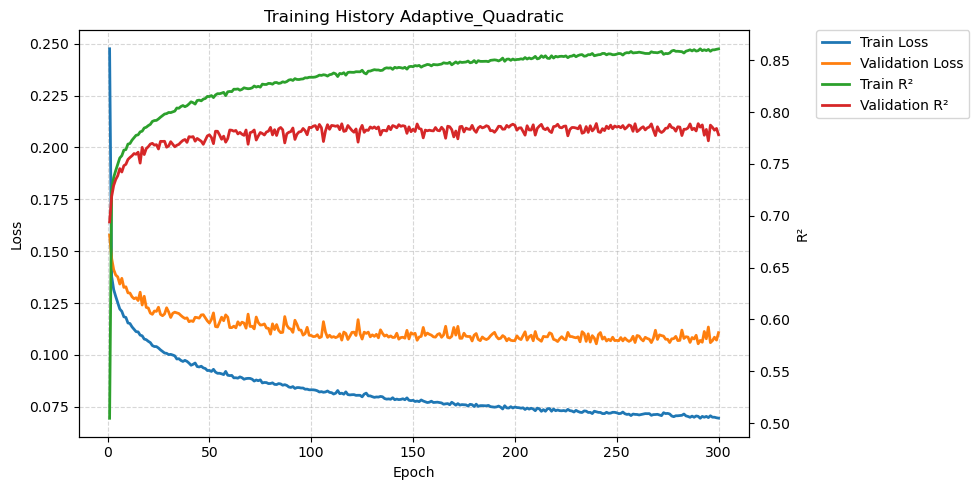

In [ ]:
tu.plot_training_history(history, "Adaptive_Quadratic")